In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
cp = checkpoint.CheckPoint("../models/MLC_d600k_nep10_best.pt", device=DEVICE)
_, val = cp.load_dataloaders("../data/base_5alphabets_per_perm_lvl", val_batch_size=1000)
model = cp.load_model()

Loading training (622,718 samples) and validation (69,191 samples) dataloaders.
Loading model that has completed (or started) 10 of 10 epochs
	batch size: 25
	number of steps:233,500
	best val loss achieved: 0.0359
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Best Validation Loss: 0.036
Best Validation Accuracy: 0.847


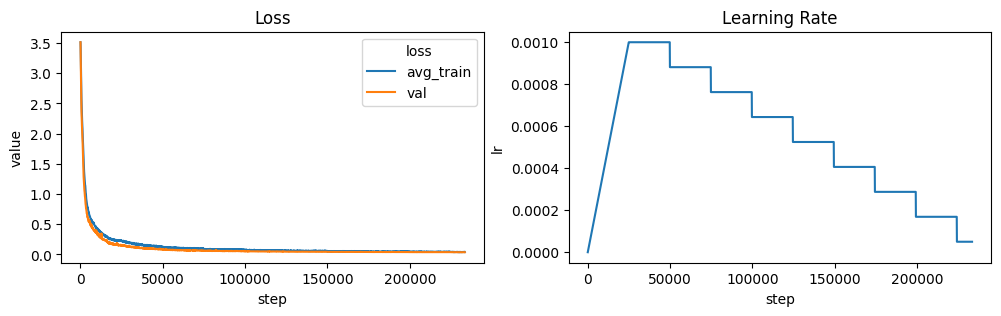

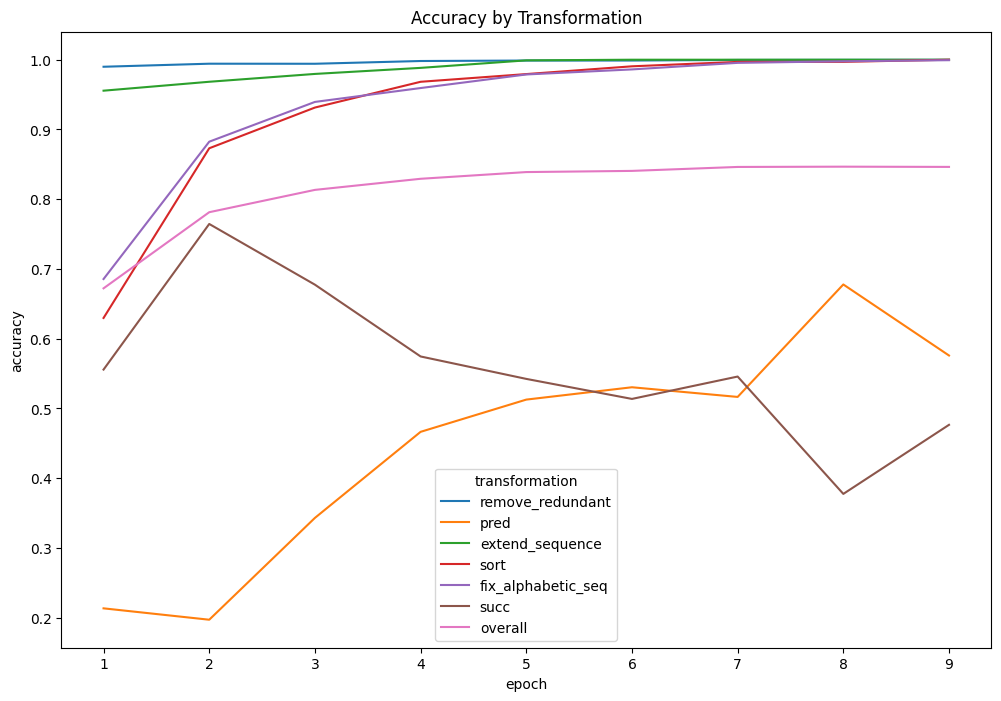

In [3]:
# plot training metrics:
fig, ax = plt.subplots(1, 2, figsize=(12,3))
ax[0] = cp.plot_loss(ax[0])
_ = ax[0].set_title("Loss")
ax[1] = cp.plot_learning_rate(ax[1])
_ = ax[1].set_title("Learning Rate")
print(f'Best Validation Loss: {cp.checkpoint["best_val_loss"]:.3f}')

val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types + ["overall"], var_name="transformation", value_name="accuracy")
print(f"Best Validation Accuracy: {val_acc.loc[val_acc["transformation"] =="overall","accuracy"].max():.3f}")
_ = plt.figure(figsize=(12,8))
_ = sns.lineplot(val_acc, x="epoch", y="accuracy", hue="transformation")
_ = plt.title("Accuracy by Transformation")

In [4]:
keep_cols = [
    'n_perm',
    'problem',
    'xq',
    'transformation',
    'query_length',
    'yq',
    'alphabet',
    'study',
    'pred'
]
pred_data = analysis_utils.predict_dataset(val, model, keep_cols=keep_cols)
# save prediction data to disk
pred_data.to_csv("prediction_data/pred_" + cp.model_path.replace("../models/","").replace(".pt","") + ".csv", index=False)
# split into correct and incorrect samples
correct_pred = pred_data[pred_data["correct"]==True]
incorrect_pred = pred_data[pred_data["correct"]==False]

Predicting:   0%|          | 0/70 [00:00<?, ?it/s]c:\Users\phili\anaconda3\envs\mlc-ls\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Predicting: 100%|██████████| 70/70 [07:00<00:00,  6.01s/it]


In [5]:
correct_pred[pred_data["transformation"].isin(["succ","pred"])].sample(5)

C:\Users\phili\AppData\Local\Temp\ipykernel_2368\103429640.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  correct_pred[pred_data["transformation"].isin(["succ","pred"])].sample(5)


,n_perm,problem,xq,transformation,query_length,yq,alphabet,study,pred,correct
4074,10,p q r u > o q r u,"[p, q, r, u]",pred,4,"[o, q, r, u]",a b c w e f g m s n k l j h o p q r u t x v i ...,h o p q > j o p q,"[o, q, r, u]",True
6461,20,r h x > r h d,"[r, h, x]",succ,3,"[r, h, d]",m f o c a u l j q t k i s n e p g r h x d v y ...,e p g > e p r,"[r, h, d]",True
13520,10,g h i j q l m > p h i j q l m,"[g, h, i, j, q, l, m]",pred,7,"[p, h, i, j, q, l, m]",a k t d e p g h i j q l m c o b x r f s u v w ...,i j q l m > h j q l m,"[p, h, i, j, q, l, m]",True
25035,5,k l m n > j l m n,"[k, l, m, n]",pred,4,"[j, l, m, n]",w b h d e f g a i j k l m n o p q r s t u c v ...,s t u c v x y > r t u c v x y,"[j, l, m, n]",True
58935,20,w x q p > c x q p,"[w, x, q, p]",pred,4,"[c, x, q, p]",f u o t e m d h i b z a v y j s l r g k n c w ...,y j s > v j s,"[c, x, q, p]",True


In [6]:
incorrect_pred.loc[:,["alphabet","study","xq","yq","pred"]].sample(5)

,alphabet,study,xq,yq,pred
66328,y b c d n k g o i h x l m j f p q r s t u v w ...,k g o i h > k g o i x,"[j, f, p, q]","[j, f, p, r]","[m, f, p, q]"
18558,p j c m a f e n z t k l y o g v i r s q x w d ...,t k l y o g > z k l y o g,"[z, t, k]","[n, t, k]","[z, t, l]"
20608,a k t d e p g h i j q l m c o b x r f s u v w ...,m c o > m c b,"[s, u, v, w, n, y]","[s, u, v, w, n, z]","[f, u, v, w, n, y]"
15248,a b c d e f g h i j k l m n o p q r s t u v w ...,h i j k > h i j l,"[v, w, x, y]","[v, w, x, z]","[u, w, x, y]"
30576,a b c d e f g h i j k l m n o p q w s t u v r ...,c d e > c d f,"[v, r, x, y]","[v, r, x, z]","[u, r, x, y]"


In [ ]:
incorrect_pred["alternate_rule"] = "na"
incorrect_pred = incorrect_pred.apply(analysis_utils.get_alternative_rule, axis="columns")

In [8]:
print(incorrect_pred.groupby("transformation")["alternate_rule"].value_counts())
print("\nSanity Check Total Counts:")
print(incorrect_pred.groupby("transformation")["alternate_rule"].count())

transformation    alternate_rule
pred              succ              4082
remove_redundant  na                   1
sort              na                   2
succ              pred              6548
Name: count, dtype: int64

Sanity Check Total Counts:
transformation
pred                4082
remove_redundant       1
sort                   2
succ                6548
Name: alternate_rule, dtype: int64


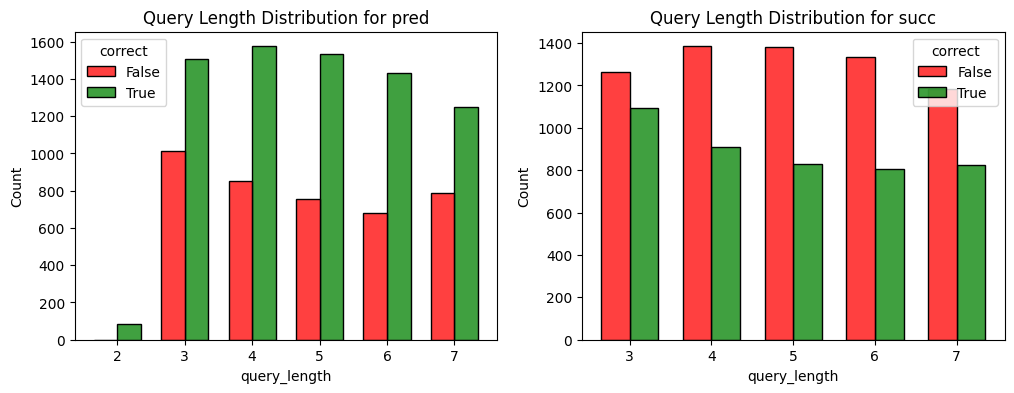

In [ ]:
palette = {True: "green", False: "red"}
fig, ax = plt.subplots(2,2, figsize=(12,8))
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[0,0])
_ = ax[0,0].set_title("Query Length Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="query_length", hue="correct", discrete=True, multiple="dodge", shrink=.7, palette=palette, ax=ax[0,1])
_ = ax[1,0].set_title("Query Length Distribution for succ")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["pred"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[1,0])
_ = ax[0,1].set_title("Num Permutations Distribution for pred")
_ = sns.histplot(pred_data[pred_data.transformation.isin(["succ"])], x="n_perm", hue="correct", discrete=True, multiple="dodge", palette=palette, ax=ax[1,1])
_ = ax[1,1].set_title("Num Permutations Distribution for succ")

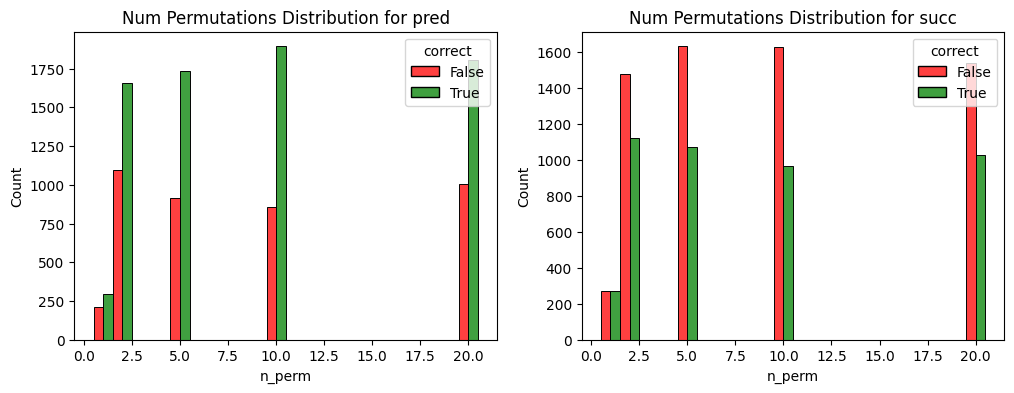

In [ ]:
#save prediction data to disk
pred_data.to_csv("prediction_data/pred_" + cp.model_path.replace("../models/","").replace(".pt","") + ".csv", index=False)